----
# <span style="color:#569CD6">Aquatic Ecosystems - lakes section</span>

# <span style="color:#569CD6">Change forcing conditions</span>
----
### <span style="color:Teal">Damien Bouffard, 2026 </span>

### <span style="color:Teal">damien.bouffard@eawag.ch </span>


----




### <span style="color:Teal">Modify files </span>

``Q$_{in}$ = Q_{river} + Q_{connection}``.  
``T{in} =  T_{river} * Q_{river} / Q_{in} + T_{connection} * Q_{connection} / Q_{in}``

Case 1. deep connection
* Q_{connection} = 30 m³/s 
* T_{connection} = (time varying) taken from deep water from Lake Murten (as no data from lake Schiffenen are provided in this assignment)

Case 2. mid depth connection
* Q_{connection} = 30 m³/s 
* T_{connection} =  (time varying)  taken from mid depth water from Lake Murten (as no data from lake ffenen are provided in this assignment)

Case 3. surface connection
* Q_{connection} = 30 m³/s 
* T_{connection} =   (time varying)  taken from surface water from Lake Murten (as no data from lake Schiffenen are provided in this assignment)

----


## <span style="color:Salmon">Import the libraries</span>


In [1]:
# import the libraries

import pandas as pd
import matplotlib.pyplot as plt
import glob 
import os 
import numpy as np
import datetime

plt.rcParams.update({'font.size': 12})


## <span style="color:Salmon"> Load lake temperature data</span>


In [2]:
# load the data
mydir='../data/Results/'
myfile='T_out.dat'
os.path.join(mydir, myfile)

# create a dataframe
df_T = pd.read_csv(os.path.join(mydir, myfile))
df_T.head()

,Datetime,-45.000,-44.000,-43.000,-42.000,-41.000,-40.000,-39.000,-38.000,-37.000,...,-9.000,-8.000,-7.000,-6.000,-5.000,-4.000,-3.000,-2.000,-1.000,-0.000
0.00,5.0580,5.0580,5.0580,5.0580,5.0580,5.0618,5.0888,5.1196,5.1504,5.1812,...,5.0847,5.0753,5.0661,5.0575,5.0458,5.0150,4.9810,4.9526,4.9575,4.9654
0.25,5.0931,5.0946,5.0984,5.1040,5.1116,5.1213,5.1332,5.1476,5.1643,5.1825,...,5.0689,5.0620,5.0551,5.0480,5.0407,5.0332,5.0253,5.0163,5.0046,4.9893
0.50,5.1624,5.1629,5.1639,5.1654,5.1671,5.1691,5.1711,5.1731,5.1750,5.1766,...,5.0625,5.0590,5.0556,5.0523,5.0493,5.0465,5.0439,5.0414,5.0384,5.0345
0.75,5.1692,5.1691,5.1688,5.1683,5.1677,5.1669,5.1659,5.1648,5.1634,5.1617,...,5.0544,5.0498,5.0447,5.0393,5.0332,5.0266,5.0189,5.0096,4.9959,4.9772
1.00,5.1552,5.1550,5.1545,5.1538,5.1529,5.1518,5.1506,5.1492,5.1476,5.1459,...,5.0108,5.0043,4.9982,4.9911,4.9834,4.9749,4.9655,4.9542,4.9384,4.9174


## <span style="color:Salmon"> Load discharge data</span>



In [3]:

mydir='../data/'
myfile='Qin.dat'
os.path.join(mydir, myfile)

df_Qin = pd.read_csv(os.path.join(mydir, myfile), sep=r'\s+', skiprows=3, names=["Time [d]", "Q_in [m3/s]"])



## <span style="color:salmon"> Load inflow temperature</span>


In [4]:
mydir='../data/'
myfile='Tin.dat'
os.path.join(mydir, myfile)

#df_Tin = pd.read_csv(os.path.join(mydir, myfile), delim_whitespace=True, skiprows=3, names=["Time [d]", "T_in [C]"])
df_Tin = pd.read_csv(os.path.join(mydir, myfile), sep=r'\s+', skiprows=3, names=["Time [d]", "T_in [C]"])


# <span style="color:#569CD6"> CASE 1 water collected at the bottom</span>
 
water is collected within the last 5 m

As there are no data from Lake Schiffenen for this work, we assume that the surface temperature of Lake Schiffenen is similar to the one from Lake Morat 

In [5]:
dT_connection = df_Tin.copy()
dT_connection = dT_connection.set_index('Time [d]')

dT_connection = dT_connection[~dT_connection.index.duplicated(keep='first')]
df_T_clean = df_T[~df_T.index.duplicated(keep='first')]

combined_index = dT_connection.index.union(df_T_clean.index)

surface_interpolated = (
    df_T_clean[['-38.000', '-37.000', '-36.000', '-35.000', '-34.000', '-33.000']].mean(axis=1)
    .reindex(combined_index)
    .interpolate(method='index')
)

dT_connection['T_connection [C]'] = surface_interpolated.reindex(dT_connection.index)
dT_connection = dT_connection.reset_index()

print(dT_connection.head())


   Time [d]  T_in [C]  T_connection [C]
0    0.0417   0.91599          5.222419
1    0.0833   0.79624          5.218664
2    0.1250   0.62658          5.214900
3    0.1667   0.57669          5.211136
4    0.2083   0.60667          5.207381


6.410341293989814

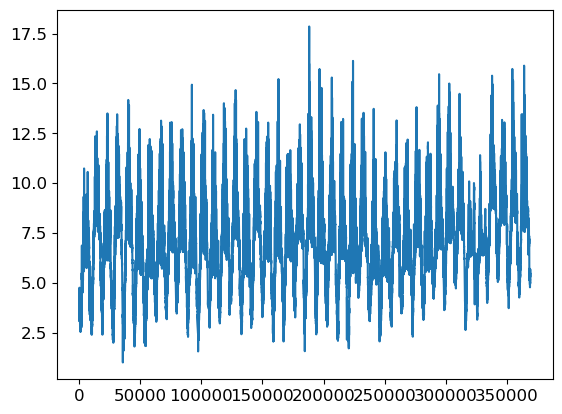

In [6]:
df_merged = pd.merge(df_Qin, dT_connection, on='Time [d]')
df_merged['Q_connection'] = 30

df_merged['Q_tot'] = df_merged['Q_in [m3/s]'] + df_merged['Q_connection']
df_merged['T_tot'] = (df_merged['Q_in [m3/s]'] * df_merged['T_in [C]'] + df_merged['Q_connection'] * df_merged['T_connection [C]']) / df_merged['Q_tot']
df_merged
df_merged['T_tot'].plot()
df_merged['T_tot'].mean()


In [7]:
# load the data
mydir = '../data/'
myfile = 'Qin.dat'
file = os.path.join(mydir, myfile)

# Read the file
with open(file, 'r') as f:
    lines = f.readlines()

# Create a lookup dict from df_merged: Time [d] -> Q_tot
q_lookup = dict(zip(df_merged['Time [d]'], df_merged['Q_tot']))

# Process the file
modified_lines = []
for i, line in enumerate(lines):
    if i <= 2:
        modified_lines.append(line)
    else:
        parts = line.split()
        if len(parts) == 2:
            time_value = float(parts[0])
            # Look up Q_tot from df_merged by time value
            new_flow_value = q_lookup.get(time_value, float(parts[1]))  # fallback to original if not found
            modified_lines.append(f"    {time_value}    {new_flow_value:.5f}\n")

# Write the modified content to a new file
with open('../data/Qin_modified_bot.dat', 'w') as f:
    f.writelines(modified_lines)

In [8]:
# load the data
mydir = '../data/'
myfile = 'Tin.dat'
file = os.path.join(mydir, myfile)

# Read the file
with open(file, 'r') as f:
    lines = f.readlines()

# Create a lookup dict from df_merged: Time [d] -> Q_tot
q_lookup = dict(zip(df_merged['Time [d]'], df_merged['T_tot']))

# Process the file
modified_lines = []
for i, line in enumerate(lines):
    if i <= 2:
        modified_lines.append(line)
    else:
        parts = line.split()
        if len(parts) == 2:
            time_value = float(parts[0])
            # Look up Q_tot from df_merged by time value
            new_flow_value = q_lookup.get(time_value, float(parts[1]))  # fallback to original if not found
            modified_lines.append(f"    {time_value}    {new_flow_value:.5f}\n")

# Write the modified content to a new file
with open('../data/Tin_modified_bot.dat', 'w') as f:
    f.writelines(modified_lines)

# <span style="color:#569CD6"> CASE 2 water collected at mid depth</span>

Water is collected between 10 and 15 m depth.

As there are no data from Lake Schiffenen for this work, we assume that the surface temperature of Lake Schiffenen is similar to the one from Lake Morat 


In [9]:
dT_connection = df_Tin.copy()
dT_connection = dT_connection.set_index('Time [d]')

dT_connection = dT_connection[~dT_connection.index.duplicated(keep='first')]
df_T_clean = df_T[~df_T.index.duplicated(keep='first')]

combined_index = dT_connection.index.union(df_T_clean.index)

surface_interpolated = (
    df_T_clean[['-10.000', '-11.000', '-12.000', '-13.000', '-14.000', '-15.000']].mean(axis=1)
    .reindex(combined_index)
    .interpolate(method='index')
)

dT_connection['T_connection [C]'] = surface_interpolated.reindex(dT_connection.index)
dT_connection = dT_connection.reset_index()

print(dT_connection.head())

   Time [d]  T_in [C]  T_connection [C]
0    0.0417   0.91599          5.124098
1    0.0833   0.79624          5.117627
2    0.1250   0.62658          5.111142
3    0.1667   0.57669          5.104656
4    0.2083   0.60667          5.098186


In [10]:
df_merged = pd.merge(df_Qin, dT_connection, on='Time [d]')
df_merged['Q_connection'] = 30

In [11]:
df_merged['Q_tot'] = df_merged['Q_in [m3/s]'] + df_merged['Q_connection']
df_merged['T_tot'] = (df_merged['Q_in [m3/s]'] * df_merged['T_in [C]'] + df_merged['Q_connection'] * df_merged['T_connection [C]']) / df_merged['Q_tot']
df_merged


,Time [d],Q_in [m3/s],T_in [C],T_connection [C],Q_connection,Q_tot,T_tot
0,0.0417,5.84478,0.91599,5.124098,30,35.84478,4.437932
1,0.0833,5.77278,0.79624,5.117627,30,35.77278,4.420270
2,0.1250,5.70378,0.62658,5.111142,30,35.70378,4.394720
3,0.1667,5.67478,0.57669,5.104656,30,35.67478,4.384393
4,0.2083,5.65678,0.60667,5.098186,30,35.65678,4.385628
...,...,...,...,...,...,...,...
369380,15390.8750,4.91100,6.79000,5.512683,30,34.91100,5.692366
369381,15390.9167,4.88800,6.61000,5.512683,30,34.88800,5.666423
369382,15390.9583,4.85200,6.39000,5.512683,30,34.85200,5.634821
369383,15391.0000,4.81600,6.17000,5.512683,30,34.81600,5.603608


8.7010055392928

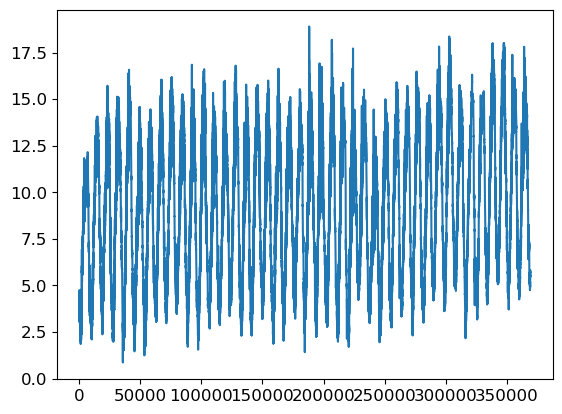

In [12]:
df_merged['T_tot'].plot()
df_merged['T_tot'].mean()

In [13]:
# load the data
mydir = '../data/'
myfile = 'Qin.dat'
file = os.path.join(mydir, myfile)

# Read the file
with open(file, 'r') as f:
    lines = f.readlines()

# Create a lookup dict from df_merged: Time [d] -> Q_tot
q_lookup = dict(zip(df_merged['Time [d]'], df_merged['Q_tot']))

# Process the file
modified_lines = []
for i, line in enumerate(lines):
    if i <= 2:
        modified_lines.append(line)
    else:
        parts = line.split()
        if len(parts) == 2:
            time_value = float(parts[0])
            # Look up Q_tot from df_merged by time value
            new_flow_value = q_lookup.get(time_value, float(parts[1]))  # fallback to original if not found
            modified_lines.append(f"    {time_value}    {new_flow_value:.5f}\n")

# Write the modified content to a new file
with open('../data/Qin_modified_mid.dat', 'w') as f:
    f.writelines(modified_lines)

In [14]:
# load the data
mydir = '../data/'
myfile = 'Tin.dat'
file = os.path.join(mydir, myfile)

# Read the file
with open(file, 'r') as f:
    lines = f.readlines()

# Create a lookup dict from df_merged: Time [d] -> Q_tot
q_lookup = dict(zip(df_merged['Time [d]'], df_merged['T_tot']))

# Process the file
modified_lines = []
for i, line in enumerate(lines):
    if i <= 2:
        modified_lines.append(line)
    else:
        parts = line.split()
        if len(parts) == 2:
            time_value = float(parts[0])
            # Look up Q_tot from df_merged by time value
            new_flow_value = q_lookup.get(time_value, float(parts[1]))  # fallback to original if not found
            modified_lines.append(f"    {time_value}    {new_flow_value:.5f}\n")

# Write the modified content to a new file
with open('../data/Tin_modified_mid.dat', 'w') as f:
    f.writelines(modified_lines)

# <span style="color:#569CD6"> CASE 3 water collected at the surface</span>

Water is collected within the first 5 m.

As there are no data from Lake Schiffenen for this work, we assume that the surface temperature of Lake Schiffenen is similar to the one from Lake Morat 


In [15]:
dT_connection = df_Tin.copy()
dT_connection = dT_connection.set_index('Time [d]')

dT_connection = dT_connection[~dT_connection.index.duplicated(keep='first')]
df_T_clean = df_T[~df_T.index.duplicated(keep='first')]

combined_index = dT_connection.index.union(df_T_clean.index)

surface_interpolated = (
    df_T_clean[['-0.000', '-1.000', '-2.000', '-3.000', '-4.000', '-5.000']].mean(axis=1)
    .reindex(combined_index)
    .interpolate(method='index')
)

dT_connection['T_connection [C]'] = surface_interpolated.reindex(dT_connection.index)
dT_connection = dT_connection.reset_index()

print(dT_connection.head())

   Time [d]  T_in [C]  T_connection [C]
0    0.0417   0.91599          4.991557
1    0.0833   0.79624          4.996885
2    0.1250   0.62658          5.002225
3    0.1667   0.57669          5.007565
4    0.2083   0.60667          5.012893


In [16]:
df_merged = pd.merge(df_Qin, dT_connection, on='Time [d]')
df_merged['Q_connection'] = 30

In [17]:
df_merged['Q_tot'] = df_merged['Q_in [m3/s]'] + df_merged['Q_connection']
df_merged['T_tot'] = (df_merged['Q_in [m3/s]'] * df_merged['T_in [C]'] + df_merged['Q_connection'] * df_merged['T_connection [C]']) / df_merged['Q_tot']
df_merged


,Time [d],Q_in [m3/s],T_in [C],T_connection [C],Q_connection,Q_tot,T_tot
0,0.0417,5.84478,0.91599,4.991557,30,35.84478,4.327003
1,0.0833,5.77278,0.79624,4.996885,30,35.77278,4.319012
2,0.1250,5.70378,0.62658,5.002225,30,35.70378,4.303203
3,0.1667,5.67478,0.57669,5.007565,30,35.67478,4.302747
4,0.2083,5.65678,0.60667,5.012893,30,35.65678,4.313866
...,...,...,...,...,...,...,...
369380,15390.8750,4.91100,6.79000,5.803483,30,34.91100,5.942259
369381,15390.9167,4.88800,6.61000,5.803483,30,34.88800,5.916481
369382,15390.9583,4.85200,6.39000,5.803483,30,34.85200,5.885137
369383,15391.0000,4.81600,6.17000,5.803483,30,34.81600,5.854183


<Axes: >

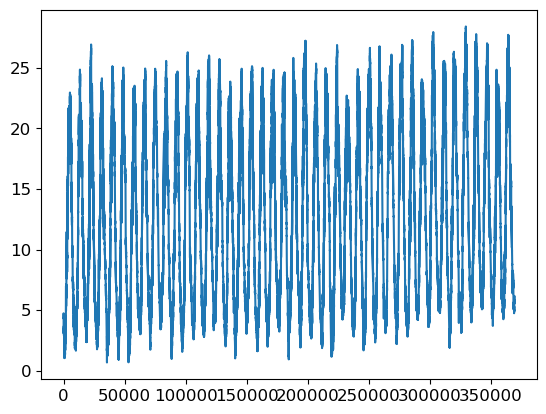

In [18]:
df_merged['T_tot'].plot()

In [19]:
# load the data
mydir = '../data/'
myfile = 'Qin.dat'
file = os.path.join(mydir, myfile)

# Read the file
with open(file, 'r') as f:
    lines = f.readlines()

# Create a lookup dict from df_merged: Time [d] -> Q_tot
q_lookup = dict(zip(df_merged['Time [d]'], df_merged['Q_tot']))

# Process the file
modified_lines = []
for i, line in enumerate(lines):
    if i <= 2:
        modified_lines.append(line)
    else:
        parts = line.split()
        if len(parts) == 2:
            time_value = float(parts[0])
            # Look up Q_tot from df_merged by time value
            new_flow_value = q_lookup.get(time_value, float(parts[1]))  # fallback to original if not found
            modified_lines.append(f"    {time_value}    {new_flow_value:.5f}\n")

# Write the modified content to a new file
with open('../data/Qin_modified_surf.dat', 'w') as f:
    f.writelines(modified_lines)

In [20]:
# load the data
mydir = '../data/'
myfile = 'Tin.dat'
file = os.path.join(mydir, myfile)

# Read the file
with open(file, 'r') as f:
    lines = f.readlines()

# Create a lookup dict from df_merged: Time [d] -> Q_tot
q_lookup = dict(zip(df_merged['Time [d]'], df_merged['T_tot']))

# Process the file
modified_lines = []
for i, line in enumerate(lines):
    if i <= 2:
        modified_lines.append(line)
    else:
        parts = line.split()
        if len(parts) == 2:
            time_value = float(parts[0])
            # Look up Q_tot from df_merged by time value
            new_flow_value = q_lookup.get(time_value, float(parts[1]))  # fallback to original if not found
            modified_lines.append(f"    {time_value}    {new_flow_value:.5f}\n")

# Write the modified content to a new file
with open('../data/Tin_modified_surf.dat', 'w') as f:
    f.writelines(modified_lines)